Que1.-
In this dataset you have to predict that whether we have to give ATTORNEY to the clients or not (0=Yes, 1=No) based on below factors.
CLMAGE - Age of Client
CLMSEX - Sex of client (0=Male, 1= Female)
SEATBELT - Whether client has Seatbelt or not (0=Yes, 1=No)
CLMINSUR - Whether Client give Insurance or not (0=Yes, 1=No)
LOSS - Loss that client faced

Prepare model by using AdaBoost, XGBoost & CATBoost & Also calculate Accuracy by confusion matrix, Calculate accuracy score, precision score, recall score, f1 score.

Dataset : Claimants.csv

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import accuracy_score, confusion_matrix, precision_score, recall_score, f1_score, classification_report
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier
import xgboost as xgb
from catboost import CatBoostClassifier
import warnings
warnings.filterwarnings('ignore')

In [2]:
df1 = pd.read_csv('E:\PGCP -BDA\Machine_Learning\Assignments\Datasets./claimants.csv')
df1.head()

,ATTORNEY,CLMSEX,CLMINSUR,SEATBELT,CLMAGE,LOSS
0,0,0.0,1.0,0.0,50.0,34.940
1,1,1.0,0.0,0.0,18.0,0.891
2,1,0.0,1.0,0.0,5.0,0.330
3,0,0.0,1.0,1.0,31.0,0.037
4,1,0.0,1.0,0.0,30.0,0.038


In [3]:
df1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1340 entries, 0 to 1339
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   ATTORNEY  1340 non-null   int64  
 1   CLMSEX    1328 non-null   float64
 2   CLMINSUR  1299 non-null   float64
 3   SEATBELT  1292 non-null   float64
 4   CLMAGE    1151 non-null   float64
 5   LOSS      1340 non-null   float64
dtypes: float64(5), int64(1)
memory usage: 62.9 KB


In [4]:
df1.isnull().sum()

ATTORNEY      0
CLMSEX       12
CLMINSUR     41
SEATBELT     48
CLMAGE      189
LOSS          0
dtype: int64

In [5]:
# Handle missing values
df1['CLMAGE'] = df1['CLMAGE'].fillna(df1['CLMAGE'].median())
df1 = df1.dropna()

In [6]:
X1 = df1[['CLMSEX', 'CLMINSUR', 'SEATBELT', 'CLMAGE', 'LOSS']]
y1 = df1['ATTORNEY']

In [7]:
X1_train, X1_test, y1_train, y1_test = train_test_split(X1, y1, test_size=0.2, random_state=42)

In [8]:

scaler = StandardScaler()
X1_train_scaled = scaler.fit_transform(X1_train)
X1_test_scaled = scaler.transform(X1_test)

In [9]:
# AdaBoost Model
ada_model1 = AdaBoostClassifier(n_estimators=100, random_state=42)
ada_model1.fit(X1_train_scaled, y1_train)
y1_pred_ada = ada_model1.predict(X1_test_scaled)

print("ADA BOOST RESULTS - Claimants Dataset")
print("="*50)
print(f"Accuracy: {accuracy_score(y1_test, y1_pred_ada):.4f}")
print(f"Precision: {precision_score(y1_test, y1_pred_ada):.4f}")
print(f"Recall: {recall_score(y1_test, y1_pred_ada):.4f}")
print(f"F1 Score: {f1_score(y1_test, y1_pred_ada):.4f}")
print("\nConfusion Matrix:")
print(confusion_matrix(y1_test, y1_pred_ada))

ADA BOOST RESULTS - Claimants Dataset
Accuracy: 0.6929
Precision: 0.7522
Recall: 0.6296
F1 Score: 0.6855

Confusion Matrix:
[[91 28]
 [50 85]]


In [10]:
# XGBoost Model
xgb_model1 = xgb.XGBClassifier(n_estimators=100, random_state=42, eval_metric='logloss')
xgb_model1.fit(X1_train_scaled, y1_train)
y1_pred_xgb = xgb_model1.predict(X1_test_scaled)

print("XGBOOST RESULTS - Claimants Dataset")
print("="*50)
print(f"Accuracy: {accuracy_score(y1_test, y1_pred_xgb):.4f}")
print(f"Precision: {precision_score(y1_test, y1_pred_xgb):.4f}")
print(f"Recall: {recall_score(y1_test, y1_pred_xgb):.4f}")
print(f"F1 Score: {f1_score(y1_test, y1_pred_xgb):.4f}")
print("\nConfusion Matrix:")
print(confusion_matrix(y1_test, y1_pred_xgb))

XGBOOST RESULTS - Claimants Dataset
Accuracy: 0.5945
Precision: 0.6290
Recall: 0.5778
F1 Score: 0.6023

Confusion Matrix:
[[73 46]
 [57 78]]


In [11]:
# CATBoost Model
cat_model1 = CatBoostClassifier(n_estimators=100, random_seed=42, verbose=0)
cat_model1.fit(X1_train_scaled, y1_train)
y1_pred_cat = cat_model1.predict(X1_test_scaled)

print("CATBOOST RESULTS - Claimants Dataset")
print("="*50)
print(f"Accuracy: {accuracy_score(y1_test, y1_pred_cat):.4f}")
print(f"Precision: {precision_score(y1_test, y1_pred_cat):.4f}")
print(f"Recall: {recall_score(y1_test, y1_pred_cat):.4f}")
print(f"F1 Score: {f1_score(y1_test, y1_pred_cat):.4f}")
print("\nConfusion Matrix:")
print(confusion_matrix(y1_test, y1_pred_cat))

CATBOOST RESULTS - Claimants Dataset
Accuracy: 0.6850
Precision: 0.7350
Recall: 0.6370
F1 Score: 0.6825

Confusion Matrix:
[[88 31]
 [49 86]]


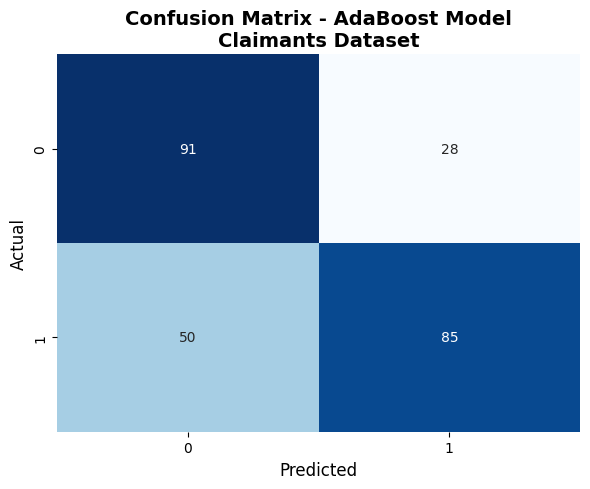

In [12]:
plt.figure(figsize=(6,5))
sns.heatmap(confusion_matrix(y1_test, y1_pred_ada), annot=True, fmt='d', cmap='Blues', cbar=False)
plt.title('Confusion Matrix - AdaBoost Model\nClaimants Dataset', fontsize=14, fontweight='bold')
plt.xlabel('Predicted', fontsize=12)
plt.ylabel('Actual', fontsize=12)
plt.tight_layout()
plt.show()

Que2.-

The model's main purpose is to predict the 10-year risk of Coronary Heart Disease (CHD). CHD is a disease of the blood vessels supplying the heart. Heart disease has been the leading cause of death worldwide since 1921. In 2008, 7.3 million people died from CHD. 
The classification goal is to predict whether the patient has 10-year risk of future coronary heart disease (CHD).The dataset provides the patients’ information. It includes over 4,000 records and 15 attributes.
Variables
Sex: male or female(0=female, 1=male)
Age: Age of the patient
education: Some high school (1), high school/GED (2), some college/vocational school (3), college (4)
Current Smoker: whether or not the patient is a current smoker (0=No, 1=Yes)
Cigs Per Day: the number of cigarettes that the person smoked on average in one day
BP Meds: whether or not the patient was on blood pressure medication 
Prevalent Stroke: whether or not the patient had previously had a stroke (0=No, 1=Yes)
Prevalent Hyp: whether or not the patient was hypertensive (0=No, 1=Yes)
Diabetes: whether or not the patient had diabetes (0=No, 1=Yes)
Tot Chol: total cholesterol level
Sys BP: systolic blood pressure 
Dia BP: diastolic blood pressure
BMI: Body Mass Index
Heart Rate: heart rate
Glucose: glucose level

Prepare model by using AdaBoost, XGBoost & CATBoost.

Also calculate Accuracy by confusion matrix, Calculate accuracy score, precision score, recall score, f1 score.

Datasets : framingham.csv




In [13]:
df2 = pd.read_csv('E:\PGCP -BDA\Machine_Learning\Assignments\Datasets./framingham.csv')
df2.head()

,male,age,education,currentSmoker,cigsPerDay,BPMeds,prevalentStroke,prevalentHyp,diabetes,totChol,sysBP,diaBP,BMI,heartRate,glucose,TenYearCHD
0,1,39,4.0,0,0.0,0.0,0,0,0,195.0,106.0,70.0,26.97,80.0,77.0,0
1,0,46,2.0,0,0.0,0.0,0,0,0,250.0,121.0,81.0,28.73,95.0,76.0,0
2,1,48,1.0,1,20.0,0.0,0,0,0,245.0,127.5,80.0,25.34,75.0,70.0,0
3,0,61,3.0,1,30.0,0.0,0,1,0,225.0,150.0,95.0,28.58,65.0,103.0,1
4,0,46,3.0,1,23.0,0.0,0,0,0,285.0,130.0,84.0,23.10,85.0,85.0,0


In [14]:
df2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4240 entries, 0 to 4239
Data columns (total 16 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   male             4240 non-null   int64  
 1   age              4240 non-null   int64  
 2   education        4135 non-null   float64
 3   currentSmoker    4240 non-null   int64  
 4   cigsPerDay       4211 non-null   float64
 5   BPMeds           4187 non-null   float64
 6   prevalentStroke  4240 non-null   int64  
 7   prevalentHyp     4240 non-null   int64  
 8   diabetes         4240 non-null   int64  
 9   totChol          4190 non-null   float64
 10  sysBP            4240 non-null   float64
 11  diaBP            4240 non-null   float64
 12  BMI              4221 non-null   float64
 13  heartRate        4239 non-null   float64
 14  glucose          3852 non-null   float64
 15  TenYearCHD       4240 non-null   int64  
dtypes: float64(9), int64(7)
memory usage: 530.1 KB


In [15]:
df2.isnull().sum()

male                 0
age                  0
education          105
currentSmoker        0
cigsPerDay          29
BPMeds              53
prevalentStroke      0
prevalentHyp         0
diabetes             0
totChol             50
sysBP                0
diaBP                0
BMI                 19
heartRate            1
glucose            388
TenYearCHD           0
dtype: int64

In [16]:
# Handle missing values
df2 = df2.dropna()

In [17]:
# Define features and target
X2 = df2.drop('TenYearCHD', axis=1)
y2 = df2['TenYearCHD']

In [18]:
# Split the data
X2_train, X2_test, y2_train, y2_test = train_test_split(X2, y2, test_size=0.2, random_state=42)

In [19]:
# Scale the features
scaler2 = StandardScaler()
X2_train_scaled = scaler2.fit_transform(X2_train)
X2_test_scaled = scaler2.transform(X2_test)

In [20]:
# AdaBoost Model
ada_model2 = AdaBoostClassifier(n_estimators=100, random_state=42)
ada_model2.fit(X2_train_scaled, y2_train)
y2_pred_ada = ada_model2.predict(X2_test_scaled)

print("ADA BOOST RESULTS - Framingham Dataset")
print("="*50)
print(f"Accuracy: {accuracy_score(y2_test, y2_pred_ada):.4f}")
print(f"Precision: {precision_score(y2_test, y2_pred_ada):.4f}")
print(f"Recall: {recall_score(y2_test, y2_pred_ada):.4f}")
print(f"F1 Score: {f1_score(y2_test, y2_pred_ada):.4f}")
print("\nConfusion Matrix:")
print(confusion_matrix(y2_test, y2_pred_ada))

ADA BOOST RESULTS - Framingham Dataset
Accuracy: 0.8388
Precision: 0.6667
Recall: 0.0656
F1 Score: 0.1194

Confusion Matrix:
[[606   4]
 [114   8]]


In [21]:
# XGBoost Model
xgb_model2 = xgb.XGBClassifier(n_estimators=100, random_state=42, eval_metric='logloss')
xgb_model2.fit(X2_train_scaled, y2_train)
y2_pred_xgb = xgb_model2.predict(X2_test_scaled)

print("XGBOOST RESULTS - Framingham Dataset")
print("="*50)
print(f"Accuracy: {accuracy_score(y2_test, y2_pred_xgb):.4f}")
print(f"Precision: {precision_score(y2_test, y2_pred_xgb):.4f}")
print(f"Recall: {recall_score(y2_test, y2_pred_xgb):.4f}")
print(f"F1 Score: {f1_score(y2_test, y2_pred_xgb):.4f}")
print("\nConfusion Matrix:")
print(confusion_matrix(y2_test, y2_pred_xgb))

XGBOOST RESULTS - Framingham Dataset
Accuracy: 0.8210
Precision: 0.3636
Recall: 0.0984
F1 Score: 0.1548

Confusion Matrix:
[[589  21]
 [110  12]]


In [22]:
# CATBoost Model
cat_model2 = CatBoostClassifier(n_estimators=100, random_seed=42, verbose=0)
cat_model2.fit(X2_train_scaled, y2_train)
y2_pred_cat = cat_model2.predict(X2_test_scaled)

print("CATBOOST RESULTS - Framingham Dataset")
print("="*50)
print(f"Accuracy: {accuracy_score(y2_test, y2_pred_cat):.4f}")
print(f"Precision: {precision_score(y2_test, y2_pred_cat):.4f}")
print(f"Recall: {recall_score(y2_test, y2_pred_cat):.4f}")
print(f"F1 Score: {f1_score(y2_test, y2_pred_cat):.4f}")
print("\nConfusion Matrix:")
print(confusion_matrix(y2_test, y2_pred_cat))

CATBOOST RESULTS - Framingham Dataset
Accuracy: 0.8374
Precision: 0.7143
Recall: 0.0410
F1 Score: 0.0775

Confusion Matrix:
[[608   2]
 [117   5]]


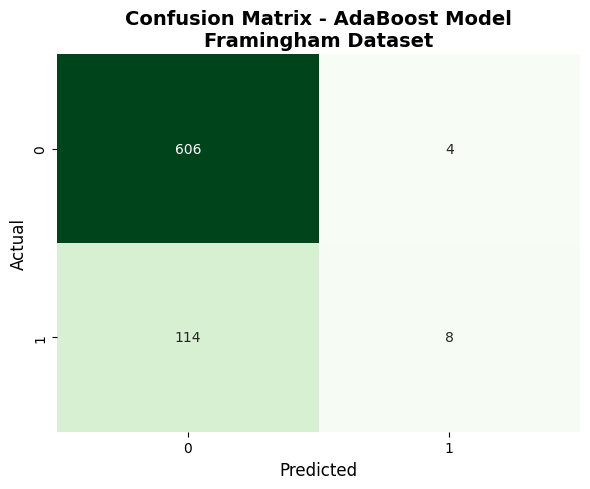

In [23]:
plt.figure(figsize=(6,5))
sns.heatmap(confusion_matrix(y2_test, y2_pred_ada), annot=True, fmt='d', cmap='Greens', cbar=False)
plt.title('Confusion Matrix - AdaBoost Model\nFramingham Dataset', fontsize=14, fontweight='bold')
plt.xlabel('Predicted', fontsize=12)
plt.ylabel('Actual', fontsize=12)
plt.tight_layout()
plt.show()

Que.3 -

Prepare a model for glass classification using Decision Tree, Random Forest, AdaBoost, XGBoost & CATBoost.
Also calculate Accuracy by confusion matrix, Calculate accuracy score, precision score, recall score, f1 score.
Data Description:
RI : refractive index
Na: Sodium (unit measurement: weight percent in corresponding oxide, as are attributes 4-10)
Mg: Magnesium
AI: Aluminum
Si: Silicon
K:Potassium
Ca: Calcium
Ba: Barium
Fe: Iron
Type: Type of glass: (class attribute)
1 -- building_windows_float_processed
 2 --building_windows_non_float_processed
 3 --vehicle_windows_float_processed
 4 --vehicle_windows_non_float_processed (none in this database)
 5 --containers
 6 --tableware
 7 --headlamps

Dataset : Glass.csv


In [24]:
df3 = pd.read_csv('E:\PGCP -BDA\Machine_Learning\Assignments\Datasets./glass.csv')
df3.head()

,RI,Na,Mg,Al,Si,K,Ca,Ba,Fe,Type
0,1.52101,13.64,4.49,1.10,71.78,0.06,8.75,0.0,0.0,1
1,1.51761,13.89,3.60,1.36,72.73,0.48,7.83,0.0,0.0,1
2,1.51618,13.53,3.55,1.54,72.99,0.39,7.78,0.0,0.0,1
3,1.51766,13.21,3.69,1.29,72.61,0.57,8.22,0.0,0.0,1
4,1.51742,13.27,3.62,1.24,73.08,0.55,8.07,0.0,0.0,1


In [25]:
df3.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 214 entries, 0 to 213
Data columns (total 10 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   RI      214 non-null    float64
 1   Na      214 non-null    float64
 2   Mg      214 non-null    float64
 3   Al      214 non-null    float64
 4   Si      214 non-null    float64
 5   K       214 non-null    float64
 6   Ca      214 non-null    float64
 7   Ba      214 non-null    float64
 8   Fe      214 non-null    float64
 9   Type    214 non-null    int64  
dtypes: float64(9), int64(1)
memory usage: 16.8 KB


In [26]:
df3.isnull().sum()

RI      0
Na      0
Mg      0
Al      0
Si      0
K       0
Ca      0
Ba      0
Fe      0
Type    0
dtype: int64

In [27]:
df3.describe()

,RI,Na,Mg,Al,Si,K,Ca,Ba,Fe,Type
count,214.000000,214.000000,214.000000,214.000000,214.000000,214.000000,214.000000,214.000000,214.000000,214.000000
mean,1.518365,13.407850,2.684533,1.444907,72.650935,0.497056,8.956963,0.175047,0.057009,2.780374
std,0.003037,0.816604,1.442408,0.499270,0.774546,0.652192,1.423153,0.497219,0.097439,2.103739
min,1.511150,10.730000,0.000000,0.290000,69.810000,0.000000,5.430000,0.000000,0.000000,1.000000
25%,1.516522,12.907500,2.115000,1.190000,72.280000,0.122500,8.240000,0.000000,0.000000,1.000000
50%,1.517680,13.300000,3.480000,1.360000,72.790000,0.555000,8.600000,0.000000,0.000000,2.000000
75%,1.519157,13.825000,3.600000,1.630000,73.087500,0.610000,9.172500,0.000000,0.100000,3.000000
max,1.533930,17.380000,4.490000,3.500000,75.410000,6.210000,16.190000,3.150000,0.510000,7.000000


In [28]:
X3 = df3.drop('Type', axis=1)
y3 = df3['Type']

In [29]:
le3 = LabelEncoder()
y3_encoded = le3.fit_transform(y3)

In [30]:
from sklearn.preprocessing import LabelEncoder

In [31]:
X3_train, X3_test, y3_train, y3_test = train_test_split(X3, y3_encoded, test_size=0.2, random_state=42)

In [32]:
scaler3 = StandardScaler()
X3_train_scaled = scaler3.fit_transform(X3_train)
X3_test_scaled = scaler3.transform(X3_test)

In [33]:
dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X3_train_scaled, y3_train)
y3_pred_dt = dt_model.predict(X3_test_scaled)

print("DECISION TREE RESULTS - Glass Dataset")
print("="*50)
print(f"Accuracy: {accuracy_score(y3_test, y3_pred_dt):.4f}")
print(f"Precision (macro): {precision_score(y3_test, y3_pred_dt, average='macro'):.4f}")
print(f"Recall (macro): {recall_score(y3_test, y3_pred_dt, average='macro'):.4f}")
print(f"F1 Score (macro): {f1_score(y3_test, y3_pred_dt, average='macro'):.4f}")
print("\nConfusion Matrix:")
print(confusion_matrix(y3_test, y3_pred_dt))

DECISION TREE RESULTS - Glass Dataset
Accuracy: 0.7209
Precision (macro): 0.7233
Recall (macro): 0.7210
F1 Score (macro): 0.6974

Confusion Matrix:
[[10  0  0  1  0  0]
 [ 4  7  2  0  0  1]
 [ 0  0  3  0  0  0]
 [ 0  3  0  1  0  0]
 [ 0  1  0  0  2  0]
 [ 0  0  0  0  0  8]]


In [34]:
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X3_train_scaled, y3_train)
y3_pred_rf = rf_model.predict(X3_test_scaled)

print("RANDOM FOREST RESULTS - Glass Dataset")
print("="*50)
print(f"Accuracy: {accuracy_score(y3_test, y3_pred_rf):.4f}")
print(f"Precision (macro): {precision_score(y3_test, y3_pred_rf, average='macro'):.4f}")
print(f"Recall (macro): {recall_score(y3_test, y3_pred_rf, average='macro'):.4f}")
print(f"F1 Score (macro): {f1_score(y3_test, y3_pred_rf, average='macro'):.4f}")
print("\nConfusion Matrix:")
print(confusion_matrix(y3_test, y3_pred_rf))

RANDOM FOREST RESULTS - Glass Dataset
Accuracy: 0.8372
Precision (macro): 0.9127
Recall (macro): 0.8433
F1 Score (macro): 0.8605

Confusion Matrix:
[[11  0  0  0  0  0]
 [ 4  9  0  0  0  1]
 [ 1  0  2  0  0  0]
 [ 0  1  0  3  0  0]
 [ 0  0  0  0  3  0]
 [ 0  0  0  0  0  8]]


In [35]:
ada_model3 = AdaBoostClassifier(n_estimators=100, random_state=42)
ada_model3.fit(X3_train_scaled, y3_train)
y3_pred_ada = ada_model3.predict(X3_test_scaled)

print("ADA BOOST RESULTS - Glass Dataset")
print("="*50)
print(f"Accuracy: {accuracy_score(y3_test, y3_pred_ada):.4f}")
print(f"Precision (macro): {precision_score(y3_test, y3_pred_ada, average='macro'):.4f}")
print(f"Recall (macro): {recall_score(y3_test, y3_pred_ada, average='macro'):.4f}")
print(f"F1 Score (macro): {f1_score(y3_test, y3_pred_ada, average='macro'):.4f}")
print("\nConfusion Matrix:")
print(confusion_matrix(y3_test, y3_pred_ada))

ADA BOOST RESULTS - Glass Dataset
Accuracy: 0.6512
Precision (macro): 0.5463
Recall (macro): 0.5299
F1 Score (macro): 0.5242

Confusion Matrix:
[[ 8  3  0  0  0  0]
 [ 2 11  1  0  0  0]
 [ 2  1  0  0  0  0]
 [ 0  3  0  1  0  0]
 [ 0  0  0  1  2  0]
 [ 0  0  0  0  2  6]]


In [36]:
xgb_model3 = xgb.XGBClassifier(n_estimators=100, random_state=42, eval_metric='mlogloss')
xgb_model3.fit(X3_train_scaled, y3_train)
y3_pred_xgb = xgb_model3.predict(X3_test_scaled)

print("XGBOOST RESULTS - Glass Dataset")
print("="*50)
print(f"Accuracy: {accuracy_score(y3_test, y3_pred_xgb):.4f}")
print(f"Precision (macro): {precision_score(y3_test, y3_pred_xgb, average='macro'):.4f}")
print(f"Recall (macro): {recall_score(y3_test, y3_pred_xgb, average='macro'):.4f}")
print(f"F1 Score (macro): {f1_score(y3_test, y3_pred_xgb, average='macro'):.4f}")
print("\nConfusion Matrix:")
print(confusion_matrix(y3_test, y3_pred_xgb))

XGBOOST RESULTS - Glass Dataset
Accuracy: 0.8372
Precision (macro): 0.8624
Recall (macro): 0.8102
F1 Score (macro): 0.8280

Confusion Matrix:
[[10  1  0  0  0  0]
 [ 1 11  0  1  0  1]
 [ 1  0  2  0  0  0]
 [ 0  2  0  2  0  0]
 [ 0  0  0  0  3  0]
 [ 0  0  0  0  0  8]]


In [37]:
# CATBoost Model
cat_model3 = CatBoostClassifier(n_estimators=100, random_seed=42, verbose=0)
cat_model3.fit(X3_train_scaled, y3_train)
y3_pred_cat = cat_model3.predict(X3_test_scaled)

print("CATBOOST RESULTS - Glass Dataset")
print("="*50)
print(f"Accuracy: {accuracy_score(y3_test, y3_pred_cat):.4f}")
print(f"Precision (macro): {precision_score(y3_test, y3_pred_cat, average='macro'):.4f}")
print(f"Recall (macro): {recall_score(y3_test, y3_pred_cat, average='macro'):.4f}")
print(f"F1 Score (macro): {f1_score(y3_test, y3_pred_cat, average='macro'):.4f}")

CATBOOST RESULTS - Glass Dataset
Accuracy: 0.9070
Precision (macro): 0.8889
Recall (macro): 0.9226
F1 Score (macro): 0.9016


In [38]:
cat_model3 = CatBoostClassifier(n_estimators=100, random_seed=42, verbose=0)
cat_model3.fit(X3_train_scaled, y3_train)
y3_pred_cat = cat_model3.predict(X3_test_scaled)

print("CATBOOST RESULTS - Glass Dataset")
print("="*50)
print(f"Accuracy: {accuracy_score(y3_test, y3_pred_cat):.4f}")
print(f"Precision (macro): {precision_score(y3_test, y3_pred_cat, average='macro'):.4f}")
print(f"Recall (macro): {recall_score(y3_test, y3_pred_cat, average='macro'):.4f}")
print(f"F1 Score (macro): {f1_score(y3_test, y3_pred_cat, average='macro'):.4f}")
print("\nConfusion Matrix:")
print(confusion_matrix(y3_test, y3_pred_cat))

CATBOOST RESULTS - Glass Dataset
Accuracy: 0.9070
Precision (macro): 0.8889
Recall (macro): 0.9226
F1 Score (macro): 0.9016

Confusion Matrix:
[[11  0  0  0  0  0]
 [ 1 11  1  1  0  0]
 [ 0  0  3  0  0  0]
 [ 0  1  0  3  0  0]
 [ 0  0  0  0  3  0]
 [ 0  0  0  0  0  8]]


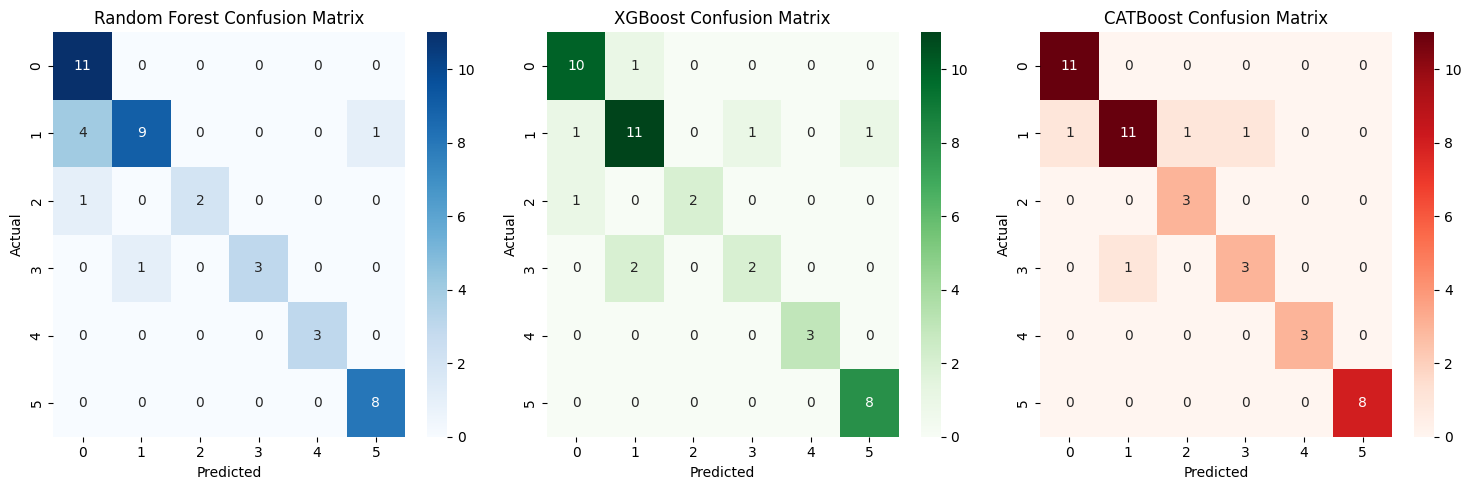

In [39]:
plt.figure(figsize=(15,5))

plt.subplot(1,3,1)
sns.heatmap(confusion_matrix(y3_test, y3_pred_rf), annot=True, fmt='d', cmap='Blues')
plt.title('Random Forest Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')

plt.subplot(1,3,2)
sns.heatmap(confusion_matrix(y3_test, y3_pred_xgb), annot=True, fmt='d', cmap='Greens')
plt.title('XGBoost Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')

plt.subplot(1,3,3)
sns.heatmap(confusion_matrix(y3_test, y3_pred_cat), annot=True, fmt='d', cmap='Reds')
plt.title('CATBoost Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')

plt.tight_layout()
plt.show()

In [40]:
results_df = pd.DataFrame({
    'Model': ['Decision Tree', 'Random Forest', 'AdaBoost', 'XGBoost', 'CATBoost'],
    'Accuracy': [
        accuracy_score(y3_test, y3_pred_dt),
        accuracy_score(y3_test, y3_pred_rf),
        accuracy_score(y3_test, y3_pred_ada),
        accuracy_score(y3_test, y3_pred_xgb),
        accuracy_score(y3_test, y3_pred_cat)
    ],
    'Precision (macro)': [
        precision_score(y3_test, y3_pred_dt, average='macro'),
        precision_score(y3_test, y3_pred_rf, average='macro'),
        precision_score(y3_test, y3_pred_ada, average='macro'),
        precision_score(y3_test, y3_pred_xgb, average='macro'),
        precision_score(y3_test, y3_pred_cat, average='macro')
    ],
    'Recall (macro)': [
        recall_score(y3_test, y3_pred_dt, average='macro'),
        recall_score(y3_test, y3_pred_rf, average='macro'),
        recall_score(y3_test, y3_pred_ada, average='macro'),
        recall_score(y3_test, y3_pred_xgb, average='macro'),
        recall_score(y3_test, y3_pred_cat, average='macro')
    ],
    'F1 Score (macro)': [
        f1_score(y3_test, y3_pred_dt, average='macro'),
        f1_score(y3_test, y3_pred_rf, average='macro'),
        f1_score(y3_test, y3_pred_ada, average='macro'),
        f1_score(y3_test, y3_pred_xgb, average='macro'),
        f1_score(y3_test, y3_pred_cat, average='macro')
    ]
})

print("\n" + "="*80)
print("MODEL COMPARISON - Glass Dataset")
print("="*80)
print(results_df.to_string(index=False))


MODEL COMPARISON - Glass Dataset
        Model  Accuracy  Precision (macro)  Recall (macro)  F1 Score (macro)
Decision Tree  0.720930           0.723256        0.720960          0.697418
Random Forest  0.837209           0.912731        0.843254          0.860522
     AdaBoost  0.651163           0.546296        0.529942          0.524176
      XGBoost  0.837209           0.862434        0.810245          0.827981
     CATBoost  0.906977           0.888889        0.922619          0.901636


Que.4 

Implement a  AdaBoost, XGBoost & CATBoost model to classify the type of animals in the zoo in to different categories.
Also calculate Accuracy by confusion matrix, Calculate accuracy score, precision score, recall score, f1 score.

Dataset : Zoo.csv

In [41]:
df4 = pd.read_csv('E:\PGCP -BDA\Machine_Learning\Assignments\Datasets./zoo.csv')
df1.head()

,ATTORNEY,CLMSEX,CLMINSUR,SEATBELT,CLMAGE,LOSS
0,0,0.0,1.0,0.0,50.0,34.940
1,1,1.0,0.0,0.0,18.0,0.891
2,1,0.0,1.0,0.0,5.0,0.330
3,0,0.0,1.0,1.0,31.0,0.037
4,1,0.0,1.0,0.0,30.0,0.038


In [53]:
# Check the target variable
print("Original classes in y4:", sorted(df4['type'].unique()))

Original classes in y4: [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7)]


In [42]:
df4.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 101 entries, 0 to 100
Data columns (total 17 columns):
 #   Column    Non-Null Count  Dtype
---  ------    --------------  -----
 0   hair      101 non-null    int64
 1   feathers  101 non-null    int64
 2   eggs      101 non-null    int64
 3   milk      101 non-null    int64
 4   airborne  101 non-null    int64
 5   aquatic   101 non-null    int64
 6   predator  101 non-null    int64
 7   toothed   101 non-null    int64
 8   backbone  101 non-null    int64
 9   breathes  101 non-null    int64
 10  venomous  101 non-null    int64
 11  fins      101 non-null    int64
 12  legs      101 non-null    int64
 13  tail      101 non-null    int64
 14  domestic  101 non-null    int64
 15  catsize   101 non-null    int64
 16  type      101 non-null    int64
dtypes: int64(17)
memory usage: 13.5 KB


In [54]:

# Define features and target
X4 = df4.drop('type', axis=1)
y4 = df4['type']

# Encode target to start from 0
le4 = LabelEncoder()
y4_encoded = le4.fit_transform(y4)

print("Encoded classes:", sorted(np.unique(y4_encoded)))
print("Mapping:", dict(zip(le4.classes_, range(len(le4.classes_)))))

Encoded classes: [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6)]
Mapping: {np.int64(1): 0, np.int64(2): 1, np.int64(3): 2, np.int64(4): 3, np.int64(5): 4, np.int64(6): 5, np.int64(7): 6}


In [55]:
# Split the data using encoded y
X4_train, X4_test, y4_train, y4_test = train_test_split(X4, y4_encoded, test_size=0.2, random_state=42)

print("Training classes:", np.unique(y4_train))
print("Test classes:", np.unique(y4_test))

Training classes: [0 1 2 3 4 5 6]
Test classes: [0 1 2 3 5 6]


In [56]:
# Scale the features
scaler4 = StandardScaler()
X4_train_scaled = scaler4.fit_transform(X4_train)
X4_test_scaled = scaler4.transform(X4_test)

In [47]:
# AdaBoost Model
ada_model4 = AdaBoostClassifier(n_estimators=100, random_state=42)
ada_model4.fit(X4_train_scaled, y4_train)
y4_pred_ada = ada_model4.predict(X4_test_scaled)

print("ADA BOOST RESULTS - Zoo Dataset")
print("="*50)
print(f"Accuracy: {accuracy_score(y4_test, y4_pred_ada):.4f}")
print(f"Precision (macro): {precision_score(y4_test, y4_pred_ada, average='macro'):.4f}")
print(f"Recall (macro): {recall_score(y4_test, y4_pred_ada, average='macro'):.4f}")
print(f"F1 Score (macro): {f1_score(y4_test, y4_pred_ada, average='macro'):.4f}")
print("\nClassification Report:")
print(classification_report(y4_test, y4_pred_ada))

ADA BOOST RESULTS - Zoo Dataset
Accuracy: 0.8095
Precision (macro): 0.4643
Recall (macro): 0.5714
F1 Score (macro): 0.4857

Classification Report:
              precision    recall  f1-score   support

           1       1.00      1.00      1.00        12
           2       1.00      1.00      1.00         2
           3       0.00      0.00      0.00         1
           4       1.00      1.00      1.00         2
           5       0.00      0.00      0.00         0
           6       0.00      0.00      0.00         3
           7       0.25      1.00      0.40         1

    accuracy                           0.81        21
   macro avg       0.46      0.57      0.49        21
weighted avg       0.77      0.81      0.78        21



In [52]:
# XGBoost Model
xgb_model4 = xgb.XGBClassifier(n_estimators=100, random_state=42, eval_metric='mlogloss')
xgb_model4.fit(X4_train_scaled, y4_train)
y4_pred_xgb = xgb_model4.predict(X4_test_scaled)

print("XGBOOST RESULTS - Zoo Dataset")
print("="*50)
print(f"Accuracy: {accuracy_score(y4_test, y4_pred_xgb):.4f}")
print(f"Precision (macro): {precision_score(y4_test, y4_pred_xgb, average='macro'):.4f}")
print(f"Recall (macro): {recall_score(y4_test, y4_pred_xgb, average='macro'):.4f}")
print(f"F1 Score (macro): {f1_score(y4_test, y4_pred_xgb, average='macro'):.4f}")

ValueError: Invalid classes inferred from unique values of `y`.  Expected: [0 1 2 3 4 5 6], got [1 2 3 4 5 6 7]

In [50]:
# CATBoost Model
cat_model4 = CatBoostClassifier(n_estimators=100, random_seed=42, verbose=0)
cat_model4.fit(X4_train_scaled, y4_train)
y4_pred_cat = cat_model4.predict(X4_test_scaled)

print("CATBOOST RESULTS - Zoo Dataset")
print("="*50)
print(f"Accuracy: {accuracy_score(y4_test, y4_pred_cat):.4f}")
print(f"Precision (macro): {precision_score(y4_test, y4_pred_cat, average='macro'):.4f}")
print(f"Recall (macro): {recall_score(y4_test, y4_pred_cat, average='macro'):.4f}")
print(f"F1 Score (macro): {f1_score(y4_test, y4_pred_cat, average='macro'):.4f}")

CATBOOST RESULTS - Zoo Dataset
Accuracy: 0.9524
Precision (macro): 0.7778
Recall (macro): 0.8333
F1 Score (macro): 0.8000


In [51]:
plt.figure(figsize=(8,6))
sns.heatmap(confusion_matrix(y4_test, y4_pred_xgb), annot=True, fmt='d', cmap='Purples', cbar=False)
plt.title('Confusion Matrix - XGBoost Model\nZoo Dataset', fontsize=14, fontweight='bold')
plt.xlabel('Predicted', fontsize=12)
plt.ylabel('Actual', fontsize=12)
plt.tight_layout()
plt.show()

NameError: name 'y4_pred_xgb' is not defined

<Figure size 800x600 with 0 Axes>

Que.5

In Churn.csv dataset you have to predict that customer is exited or not based on various factors given in dataset.
Implement a AdaBoost, XGBoost & CATBoost model and calculate Accuracy by confusion matrix, Calculate accuracy score, precision score, recall score, f1 score.


In [ ]:
df5 = pd.read_csv('E:\PGCP -BDA\Machine_Learning\Assignments\Datasets./churn.csv')
df5.head()

In [ ]:
df5.info()

In [ ]:
# Select relevant features and handle categorical variables
df5_clean = df5[['CreditScore', 'Geography', 'Gender', 'Age', 'Tenure', 'Balance', 
                  'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary', 'Exited']]

In [ ]:
# Encode categorical variables
le_geo = LabelEncoder()
le_gender = LabelEncoder()
df5_clean['Geography'] = le_geo.fit_transform(df5_clean['Geography'])
df5_clean['Gender'] = le_gender.fit_transform(df5_clean['Gender'])

In [ ]:
# Define features and target
X5 = df5_clean.drop('Exited', axis=1)
y5 = df5_clean['Exited']

In [ ]:
# Split the data
X5_train, X5_test, y5_train, y5_test = train_test_split(X5, y5, test_size=0.2, random_state=42)

In [ ]:
# Scale the features
scaler5 = StandardScaler()
X5_train_scaled = scaler5.fit_transform(X5_train)
X5_test_scaled = scaler5.transform(X5_test)

In [ ]:
# AdaBoost Model
ada_model5 = AdaBoostClassifier(n_estimators=100, random_state=42)
ada_model5.fit(X5_train_scaled, y5_train)
y5_pred_ada = ada_model5.predict(X5_test_scaled)

print("ADA BOOST RESULTS - Churn Dataset")
print("="*50)
print(f"Accuracy: {accuracy_score(y5_test, y5_pred_ada):.4f}")
print(f"Precision: {precision_score(y5_test, y5_pred_ada):.4f}")
print(f"Recall: {recall_score(y5_test, y5_pred_ada):.4f}")
print(f"F1 Score: {f1_score(y5_test, y5_pred_ada):.4f}")
print("\nConfusion Matrix:")
print(confusion_matrix(y5_test, y5_pred_ada))

In [ ]:
# XGBoost Model
xgb_model5 = xgb.XGBClassifier(n_estimators=100, random_state=42, eval_metric='logloss')
xgb_model5.fit(X5_train_scaled, y5_train)
y5_pred_xgb = xgb_model5.predict(X5_test_scaled)

print("XGBOOST RESULTS - Churn Dataset")
print("="*50)
print(f"Accuracy: {accuracy_score(y5_test, y5_pred_xgb):.4f}")
print(f"Precision: {precision_score(y5_test, y5_pred_xgb):.4f}")
print(f"Recall: {recall_score(y5_test, y5_pred_xgb):.4f}")
print(f"F1 Score: {f1_score(y5_test, y5_pred_xgb):.4f}")
print("\nConfusion Matrix:")
print(confusion_matrix(y5_test, y5_pred_xgb))

In [ ]:
# CATBoost Model
cat_model5 = CatBoostClassifier(n_estimators=100, random_seed=42, verbose=0)
cat_model5.fit(X5_train_scaled, y5_train)
y5_pred_cat = cat_model5.predict(X5_test_scaled)

print("CATBOOST RESULTS - Churn Dataset")
print("="*50)
print(f"Accuracy: {accuracy_score(y5_test, y5_pred_cat):.4f}")
print(f"Precision: {precision_score(y5_test, y5_pred_cat):.4f}")
print(f"Recall: {recall_score(y5_test, y5_pred_cat):.4f}")
print(f"F1 Score: {f1_score(y5_test, y5_pred_cat):.4f}")
print("\nConfusion Matrix:")
print(confusion_matrix(y5_test, y5_pred_cat))

In [ ]:
plt.figure(figsize=(6,5))
sns.heatmap(confusion_matrix(y5_test, y5_pred_cat), annot=True, fmt='d', cmap='Reds', cbar=False)
plt.title('Confusion Matrix - CATBoost Model\nChurn Dataset', fontsize=14, fontweight='bold')
plt.xlabel('Predicted', fontsize=12)
plt.ylabel('Actual', fontsize=12)
plt.tight_layout()
plt.show()